# Finding the k in k-anonymity
All the other suppresion methods rely on a specific k. This notebook is all about finding the specific k we wanna use for each dataset

In [1]:
from anjana.anonymity import (
    k_anonymity,
    k_anonymity_inner,
)
import masking_effects_on_xai_techniques.hierarchies as hi
import masking_effects_on_xai_techniques.anonymized_preprocessor as anon_prep
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

In [7]:
path = "../data/usa_house/"
data = pd.read_csv(path + "data.csv")
len_data = len(data)

# Clean the data
data.dropna(inplace=True)
data = data.drop("Address", axis=1)

len_clean_data = len(data)
print(f"Dropped {len_data - len_clean_data} rows")
data.to_csv(path + "clean.csv", index=False)

Dropped 0 rows


In [8]:
categories = data.columns.to_list()

hierarchies = dict()
for cat in categories:
    hierarchies[cat] = dict(
        pd.read_csv(f"../hierarchies/usa_house/{cat}.csv", header=None)
    )

In [12]:
# check with mina what should be identified as quai identifiers
quasi_ident = list(data.columns)
quasi_ident.remove("Price")

ident = []
sens_att = "Price"

In [13]:
def load_files(path):
    anon_data = []
    target_dir = Path(path).resolve()
    files = [f for f in target_dir.glob("*") if f.is_file()]
    files = sorted(files, key=lambda p: int(p.name.rstrip(".csv")))
    files
    for file in files:
        print(file)
        anon_data.append(pd.read_csv(file).iloc[:, 1:])  # ignore index col
    return anon_data


def generate_files(k_list):
    anon_data = []
    supp_level = 20
    for k in k_list:
        print(f"Anonymizing for k={k}")
        anon_df = k_anonymity_inner(
            data, ident, quasi_ident, k, supp_level, hierarchies
        )[0]
        try:
            anon_df = anon_df.drop("index", axis=1)
        except KeyError:
            print("No index column found")
            pass
        anon_data.append(anon_df)
    print("Done anonymizing")
    return anon_data


def normalize_price(df):
    y = df["Price"]
    scaler = StandardScaler()
    y = scaler.fit_transform(y.values.reshape(-1, 1))
    y = pd.Series(y.flatten())
    df["Price"] = y


def train_classifier(df):
    df = anon_prep.encode(
        df, hierarchy_path="../hierarchies/usa_house/", skip=["Price"]
    )
    y = df["Price"]
    X = df.drop(columns=["Price"])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=0
    )
    clf = MLPRegressor(
        solver="sgd", alpha=1e-5, hidden_layer_sizes=(10), random_state=1
    )
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    return score


def plot(scores):
    df = pd.DataFrame({"k_value": k_list, "Score": scores})
    plt.figure(figsize=(10, 6))
    plt.plot(df["k_value"], df["Score"], marker="o", linestyle="-", color="blue")

    plt.xscale("log", base=2)

    plt.xlabel("k Value")
    plt.ylabel("Score")
    plt.title("Score vs. k Value Progression")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xticks(k_list)
    min_score = min(scores) - 0.005
    max_score = max(scores) + 0.005
    plt.ylim(min_score, max_score)
    plt.show()

In [14]:
load_from_files = True
k_list = [2**n for n in range(1, 9)]
if load_from_files:
    anon_data = load_files("../data/usa_house/k_3")
else:
    anon_data = generate_files(k_list)

/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/data/usa_house/k_3/2.csv
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/data/usa_house/k_3/4.csv
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/data/usa_house/k_3/8.csv
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/data/usa_house/k_3/16.csv
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/data/usa_house/k_3/32.csv
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/data/usa_house/k_3/64.csv
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/data/usa_house/k_3/128.csv
/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/data/usa_house/k_3/256.csv


In [15]:
# Normalize the Price
for df in anon_data:
    normalize_price(df)

In [16]:
scores = []
for df in anon_data:
    score = train_classifier(df)
    scores.append(score)
    print(score)

0.7193630231373164
0.7091964989991619
0.7262202074139814


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.7160212004550597
0.5407812396442417
0.5044193259766089
0.22994016331785605
0.17204070936668292


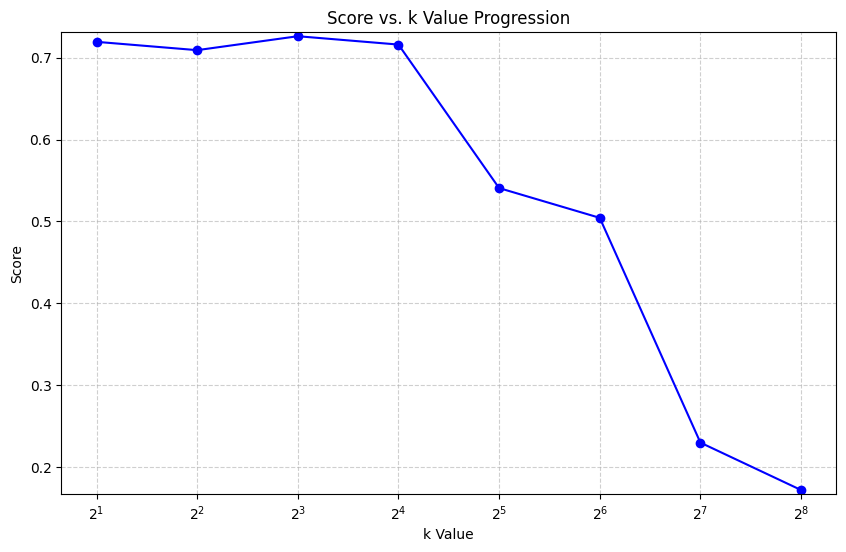

In [17]:
plot(scores)

Utility looks stable for a lot of k's. This is understandable, though, since all those datasets all satisfy a certain value for k. We pick a k of 10, just becaus it is in the range. 